In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('glass.xlsx', sheet_name=1)
df.shape 

(214, 10)

In [3]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [5]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [6]:
df.isna().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

- there are no nan values in the dataset

array([[<Axes: title={'center': 'RI'}>, <Axes: title={'center': 'Na'}>,
        <Axes: title={'center': 'Mg'}>],
       [<Axes: title={'center': 'Al'}>, <Axes: title={'center': 'Si'}>,
        <Axes: title={'center': 'K'}>],
       [<Axes: title={'center': 'Ca'}>, <Axes: title={'center': 'Ba'}>,
        <Axes: title={'center': 'Fe'}>]], dtype=object)

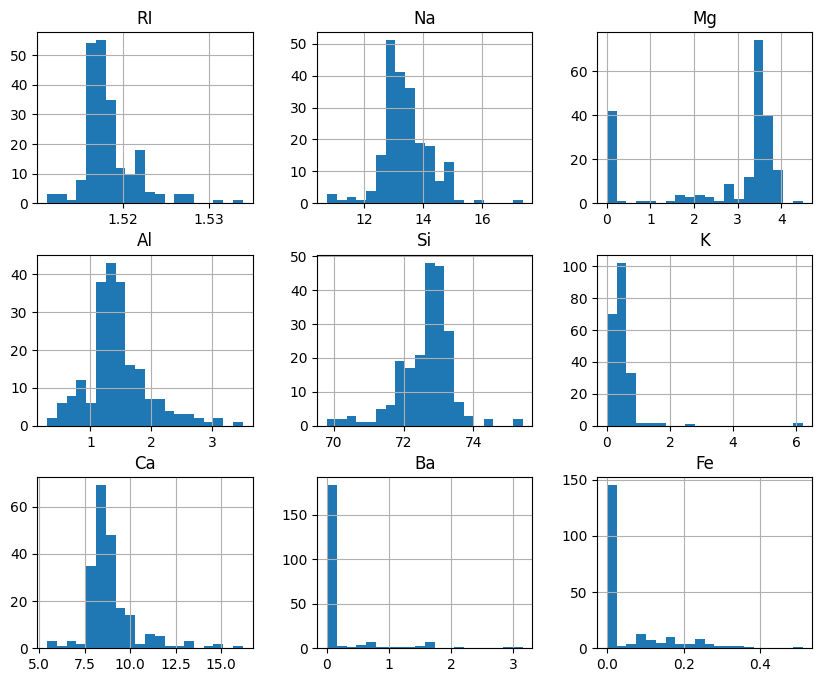

In [7]:
cols = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

df[cols].hist(figsize=(10,8), bins=20)

<Axes: >

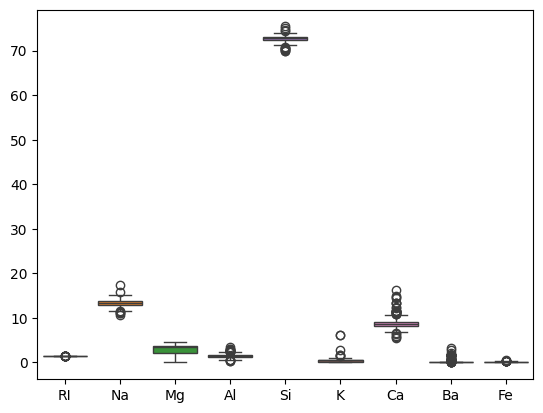

In [8]:
sns.boxplot(data= df[cols])

Outlier analysis was performed using boxplots. Several features such as Na, Al, Si, K, Ca, and Ba showed observations outside the whisker range. Since Random Forest is a tree-based algorithm and is inherently robust to outliers, these values were retained in the dataset. Removing them could potentially discard useful information relevant to glass type classification.

<Figure size 1000x800 with 0 Axes>

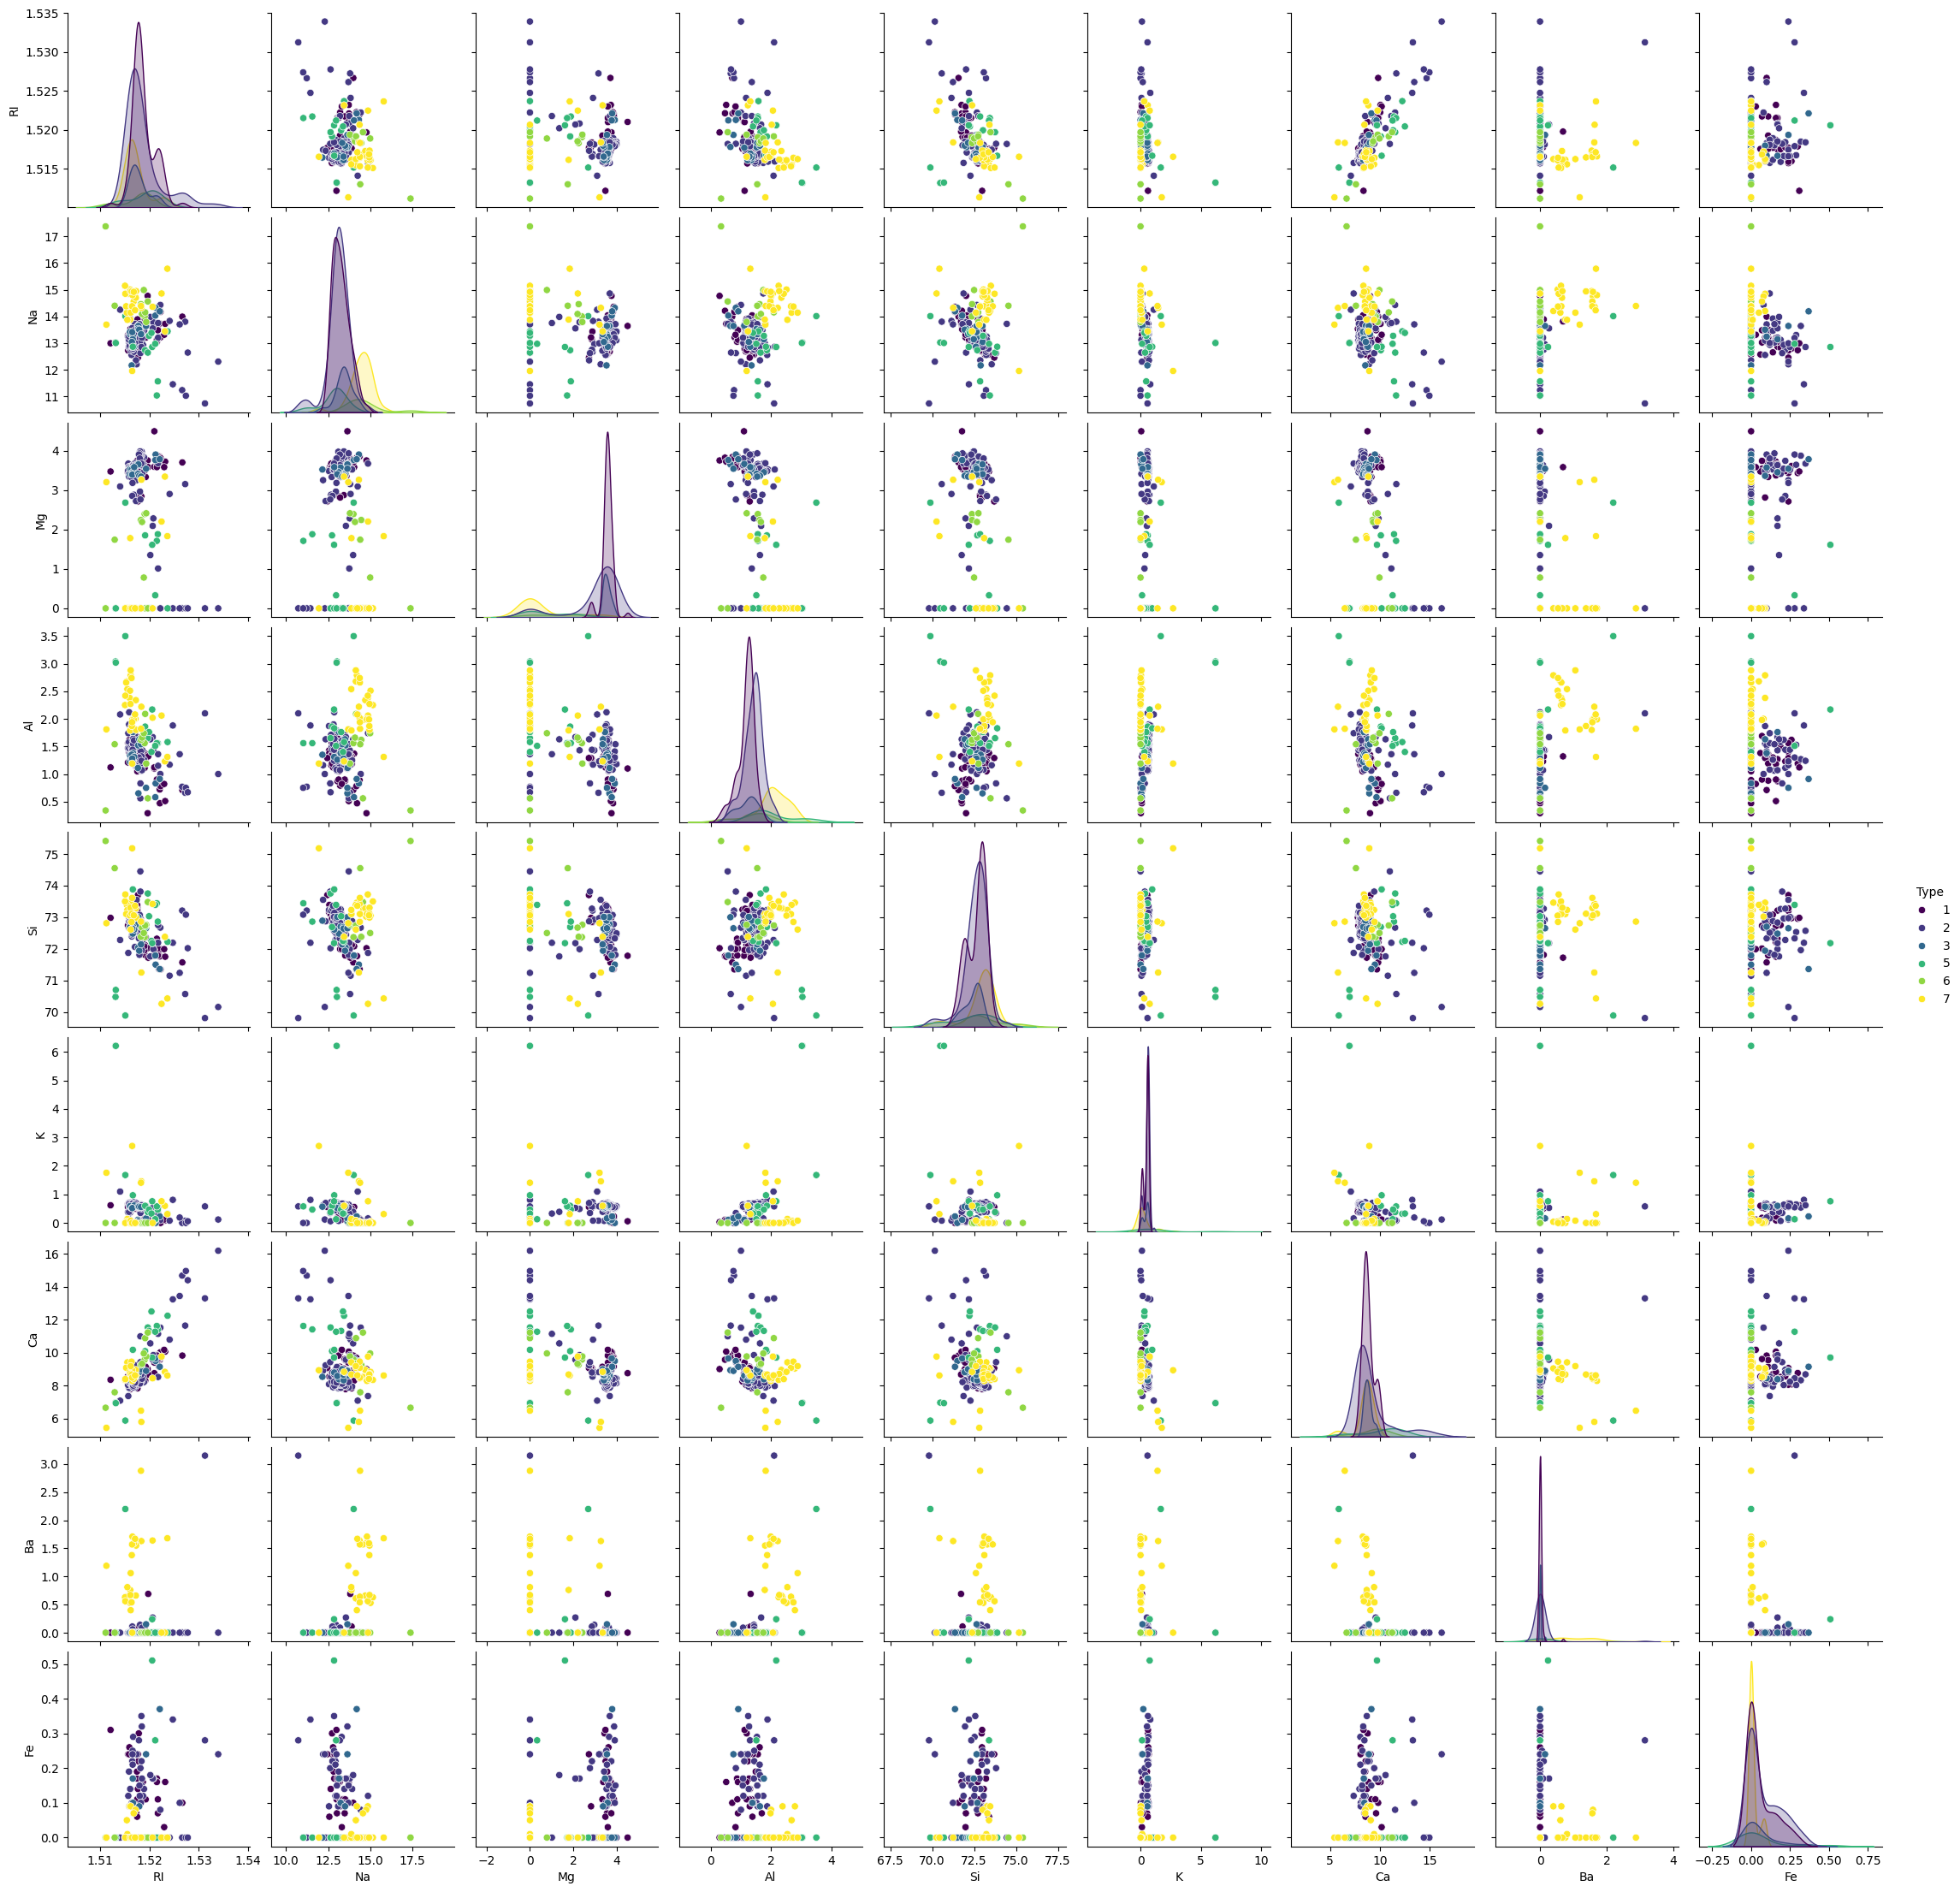

In [11]:
plt.figure(figsize=(10,8))
sns.pairplot(df, hue='Type', palette='viridis', diag_kind='kde')

Strong Positive Correlation (RI vs. Ca): there is a  clear upward diagonal trend in the plot where RI (Refractive Index) is on the Y-axis and Ca (Calcium) is on the X-axis. This suggests that as the calcium content in the glass increases, the refractive index consistently rises.

Density Differences: The diagonal plots (KDEs) show that most features, like Si (Silicon) and Na (Sodium), have fairly normal, unimodal distributions, while others like Ba (Barium) and Fe (Iron) are highly skewed, with the vast majority of values clustered near zero.

specific types of glass form distinct clusters in various feature combinations. For example, in the Ba (Barium) vs. Al (Aluminum) plots, some classes (like the yellow/greenish points) appear as distinct outliers from the main mass of the data. This indicates that certain chemical additives are highly diagnostic for specific glass types.

#### Apply feature scaling techniques such as standardization

In [12]:
# standerdization (z-score)
from sklearn.preprocessing import StandardScaler
ss =StandardScaler()

In [13]:
df_scaled = df.copy()
df_scaled[cols] = ss.fit_transform(df[cols])

In [15]:
df_scaled.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451,1
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451,1
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451,1
3,-0.232831,-0.242853,0.698710,-0.310994,-0.052974,0.112107,-0.519052,-0.352877,-0.586451,1
4,-0.312045,-0.169205,0.650066,-0.411375,0.555256,0.081369,-0.624699,-0.352877,-0.586451,1


#### 4: Random Forest Model Implementation

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
x = df_scaled.drop('Type', axis=1)
y = df_scaled['Type']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y
)

Since the target has multiple classes (1–7), stratification ensures that all classes are represented proportionally in both training and testing datasets.

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
y_pred = rf.predict(x_test)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [23]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.813953488372093
Precision: 0.8261776982707214
Recall   : 0.813953488372093
F1 Score : 0.8136212624584718

Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.85      0.73      0.79        15
           3       0.67      0.67      0.67         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.81        43
   macro avg       0.82      0.82      0.81        43
weighted avg       0.83      0.81      0.81        43



average='weighted'
- weighted → Accounts for class imbalance.

#### 5: Bagging and Boosting Methods

In [24]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [25]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(x_train, y_train)

y_pred_bag = bagging.predict(x_test)

print("Bagging Accuracy:",
      accuracy_score(y_test, y_pred_bag))

print(classification_report(y_test, y_pred_bag))

Bagging Accuracy: 0.7906976744186046
              precision    recall  f1-score   support

           1       0.79      0.79      0.79        14
           2       0.85      0.73      0.79        15
           3       0.67      0.67      0.67         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       0.86      1.00      0.92         6

    accuracy                           0.79        43
   macro avg       0.75      0.81      0.77        43
weighted avg       0.79      0.79      0.79        43



In [26]:
# AdaBoost Classifier
from sklearn.ensemble import AdaBoostClassifier

In [27]:
boosting = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boosting.fit(x_train, y_train)

y_pred_boost = boosting.predict(x_test)

print("Boosting Accuracy:",
      accuracy_score(y_test, y_pred_boost))

print(classification_report(y_test, y_pred_boost))

C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Boosting Accuracy: 0.5348837209302325
              precision    recall  f1-score   support

           1       0.54      0.93      0.68        14
           2       0.42      0.33      0.37        15
           3       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.50      1.00      0.67         2
           7       1.00      0.50      0.67         6

    accuracy                           0.53        43
   macro avg       0.41      0.46      0.40        43
weighted avg       0.48      0.53      0.48        43



C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Basavaraj M\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

The Bagging classifier significantly outperformed the Boosting classifier on the Glass dataset. Bagging achieved an accuracy of 79.07% and a weighted F1-score of 0.79, while Boosting achieved an accuracy of only 53.49% and a weighted F1-score of 0.48. Bagging demonstrated more balanced performance across all glass types, whereas Boosting failed to correctly classify some minority classes. The results suggest that variance reduction through bagging is more effective for this multiclass and moderately imbalanced dataset than the sequential error-correction approach used by AdaBoost.

#### Additional Notes:

1.Explain Bagging and Boosting methods. How is it different from each other.

Bagging (Bootstrap Aggregating)

Bagging is an ensemble learning technique that improves the performance and stability of machine learning models by combining the predictions of multiple models trained independently on different subsets of the training data. These subsets are created using bootstrap sampling (sampling with replacement).

In Bagging, each model is trained separately, and the final prediction is obtained by majority voting (for classification) or averaging (for regression).

Advantages of Bagging:
- Reduces variance and overfitting.
- Improves model stability and accuracy.
- Works well with high-variance models such as Decision Trees.
- Training can be performed in parallel.

Example: Random Forest, Bagging Classifier.

Boosting

Boosting is an ensemble learning technique that builds models sequentially. Each new model focuses on correcting the errors made by the previous model. Models are added one after another, and greater importance is given to incorrectly classified observations.

The final prediction is obtained by combining the weighted predictions of all weak learners.

Advantages of Boosting:
- Reduces bias and improves predictive accuracy.
- Learns difficult patterns in the data.
- Often achieves better performance than a single model.

Examples: AdaBoost, Gradient Boosting, XGBoost.

2.Explain how to handle imbalance in the data.

Class Imbalance

A dataset is said to be imbalanced when some classes contain significantly more samples than others. Machine learning models trained on imbalanced data tend to favor majority classes and may perform poorly on minority classes.

For example, in the Glass dataset, some glass types contain very few observations compared to others, resulting in class imbalance.

Techniques to Handle Imbalanced Data

1. Oversampling

Oversampling increases the number of samples in minority classes by duplicating existing observations or generating synthetic samples.

Example: SMOTE (Synthetic Minority Over-sampling Technique)

Advantages:
- Improves minority class representation.
- Reduces bias toward majority classes.

2. Undersampling

Undersampling reduces the number of samples in majority classes to balance the dataset.

Advantages:
- Faster training.
- Reduces dominance of majority classes.

Disadvantage:
- May remove useful information.

3. Class Weighting

Higher weights are assigned to minority classes during model training, making the model pay more attention to those classes.

Advantages:
- No data duplication required.
- Easy to implement.

4. Ensemble Methods

Ensemble techniques such as Random Forest, Balanced Random Forest, and Gradient Boosting can improve performance on imbalanced datasets by combining predictions from multiple models.

5. Appropriate Evaluation Metrics

For imbalanced datasets, accuracy alone can be misleading. Additional metrics should be considered:
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

These metrics provide a better understanding of model performance on minority classes.